In [80]:
import pandas as pd
import numpy as np
from pycaret.classification import load_model, predict_model
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import joblib

# Innit


In [81]:
# Innit
data_23_24 = pd.read_csv('../../data/joint/23-24/merged_player_data.csv')

data_36 = data_23_24[data_23_24['event'] == 36]
data_37 = data_23_24[data_23_24['event'] == 37]
data_38 = data_23_24[data_23_24['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']

data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']

data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']


In [82]:
data_23_24['event'].max()

38

# Clean Sheets


In [83]:
cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


In [84]:
# Load model
g_cs_model = load_model('../gk_cs_model')

Transformation Pipeline and Model Successfully Loaded


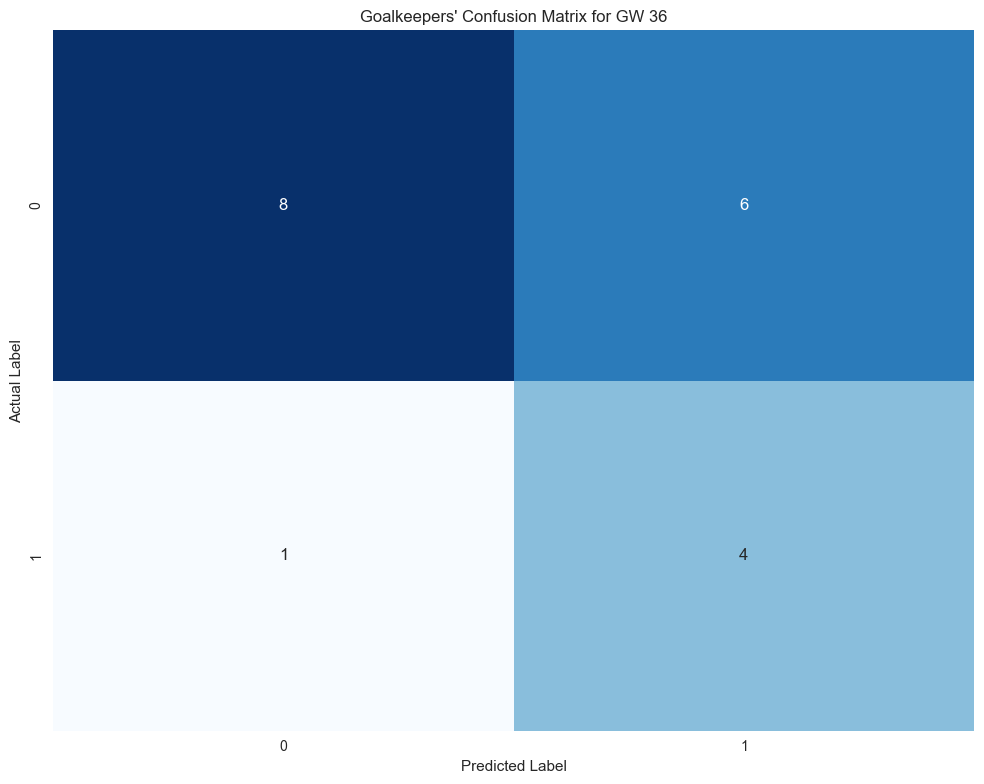

In [85]:
data_36_gk_cs = data_36_gk[cs_features]
cs = data_36_gk_cs[['clean_sheets']].copy()
data_36_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_36 = predict_model(g_cs_model, data=data_36_gk_cs)
cs_preds_36 = cs_preds_36.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_36 to data_36_gk
data_36_gk['cs_preds'] = cs_preds_36[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_36[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



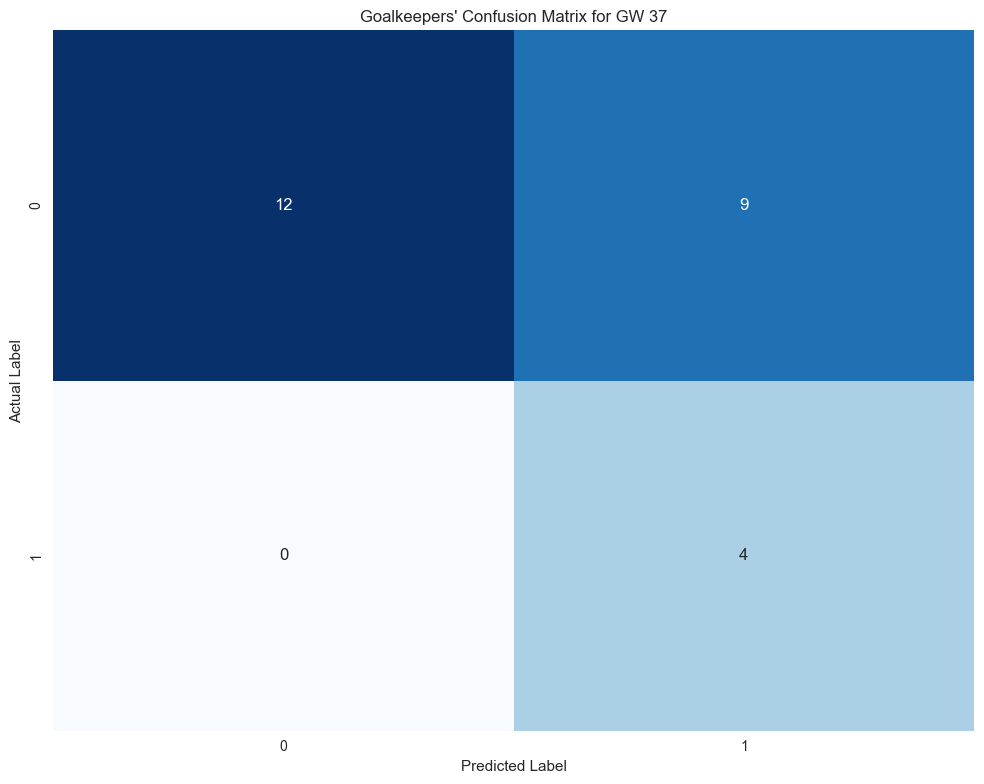

In [86]:
data_37_gk_cs = data_37_gk[cs_features]
cs = data_37_gk_cs[['clean_sheets']].copy()
data_37_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_37 = predict_model(g_cs_model, data=data_37_gk_cs)
cs_preds_37 = cs_preds_37.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_37 to data_37_gk
data_37_gk['cs_preds'] = cs_preds_37[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_37[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



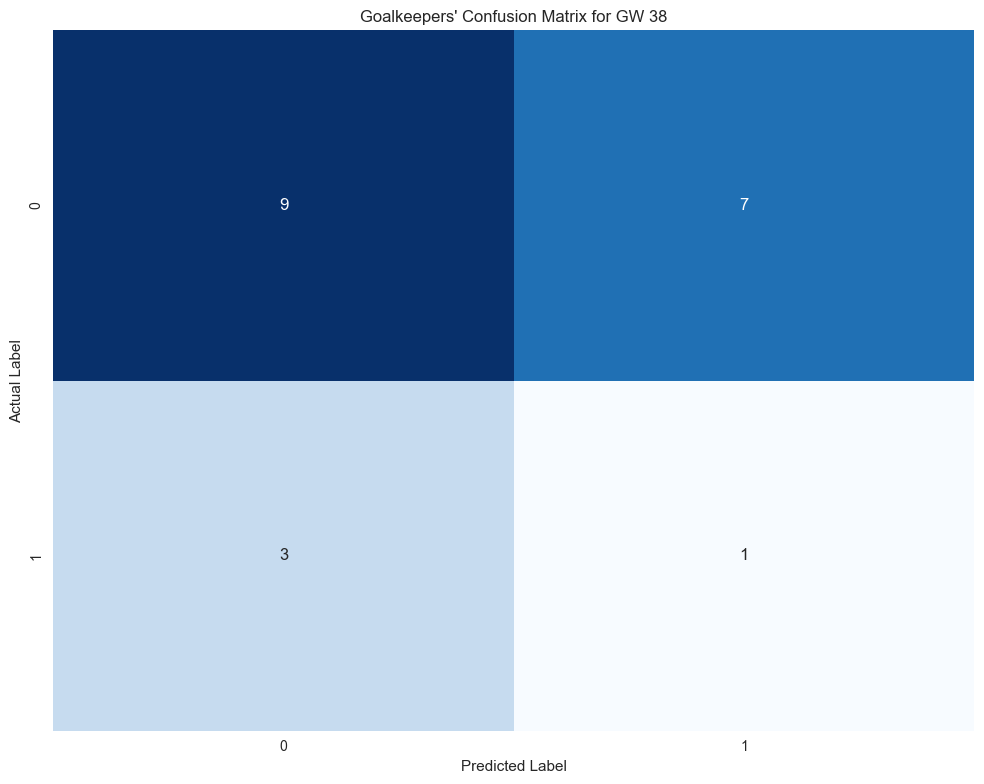

In [87]:
data_38_gk_cs = data_38_gk[cs_features]
cs = data_38_gk_cs[['clean_sheets']].copy()
data_38_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_38 = predict_model(g_cs_model, data=data_38_gk_cs)
cs_preds_38 = cs_preds_38.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_38 to data_38_gk
data_38_gk['cs_preds'] = cs_preds_38[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_38[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## DEF


In [88]:
# Load model
def_cs_model = load_model('../def_cs_model')

Transformation Pipeline and Model Successfully Loaded


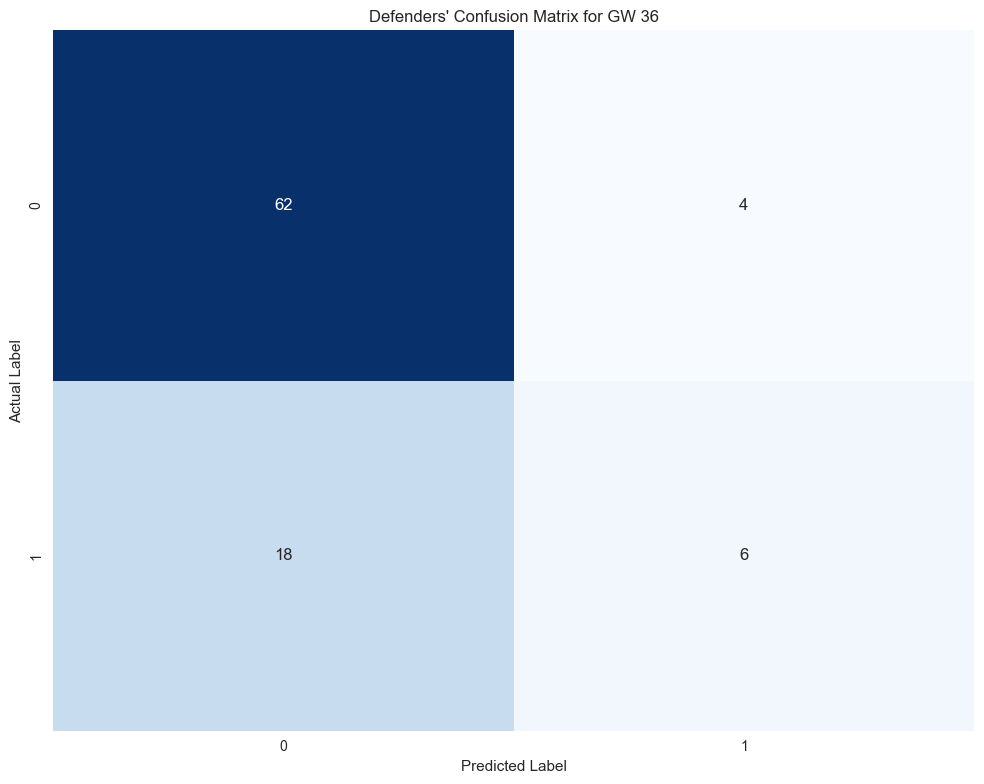

In [89]:
data_36_def_cs = data_36_def[cs_features]
cs = data_36_def_cs[['clean_sheets']].copy()
data_36_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_36 = predict_model(def_cs_model, data=data_36_def_cs)
cs_preds_36 = cs_preds_36.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_36 to data_36_def
data_36_def['cs_preds'] = cs_preds_36[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_36[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



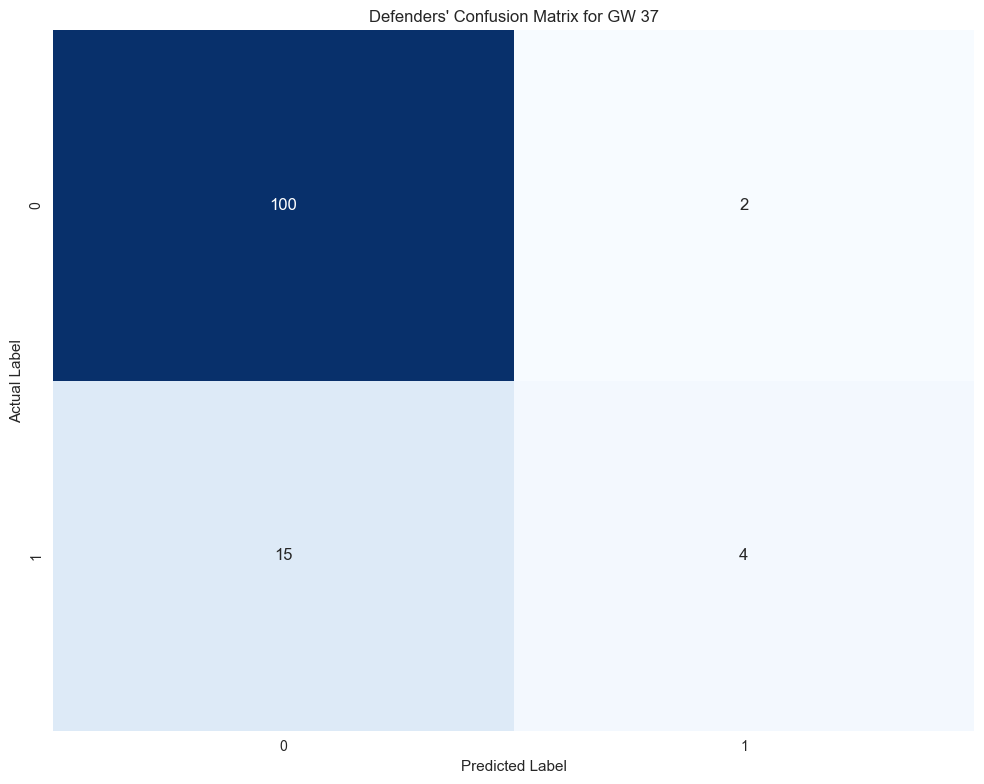

In [90]:
data_37_def_cs = data_37_def[cs_features]
cs = data_37_def_cs[['clean_sheets']].copy()
data_37_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_37 = predict_model(def_cs_model, data=data_37_def_cs)
cs_preds_37 = cs_preds_37.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_37 to data_37_def
data_37_def['cs_preds'] = cs_preds_37[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_37[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



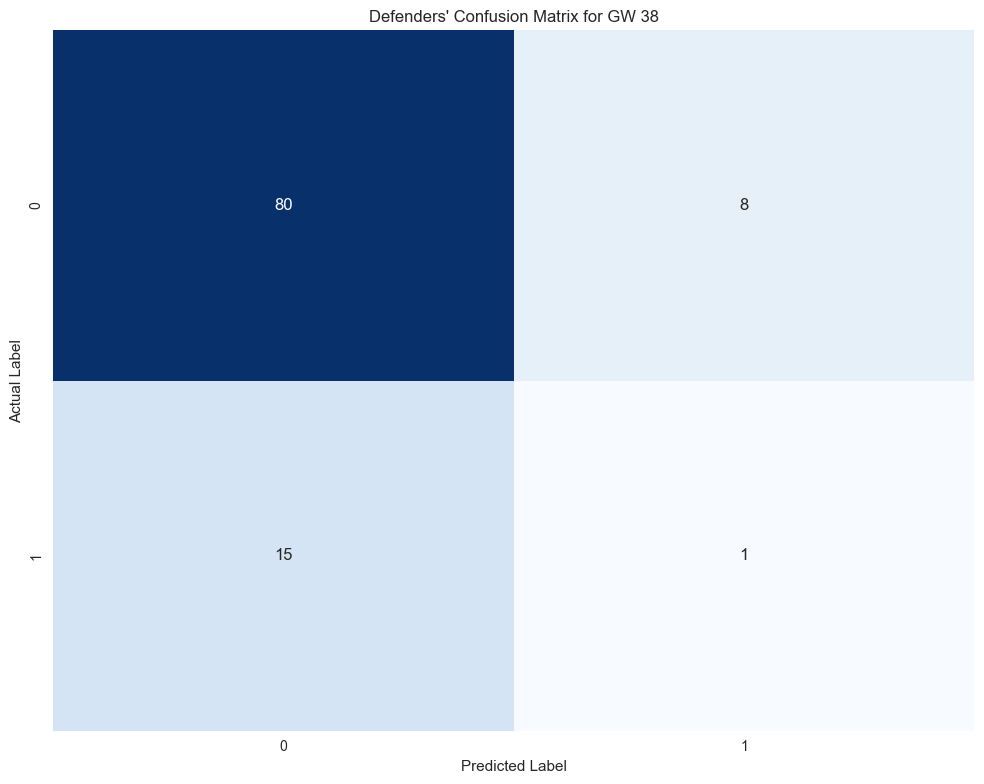

In [91]:
data_38_def_cs = data_38_def[cs_features]
cs = data_38_def_cs[['clean_sheets']].copy()
data_38_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_38 = predict_model(def_cs_model, data=data_38_def_cs)
cs_preds_38 = cs_preds_38.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_38 to data_38_def
data_38_def['cs_preds'] = cs_preds_38[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_38[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## MID


In [92]:
# Load model
mid_cs_model = load_model('../mid_cs_model')

Transformation Pipeline and Model Successfully Loaded


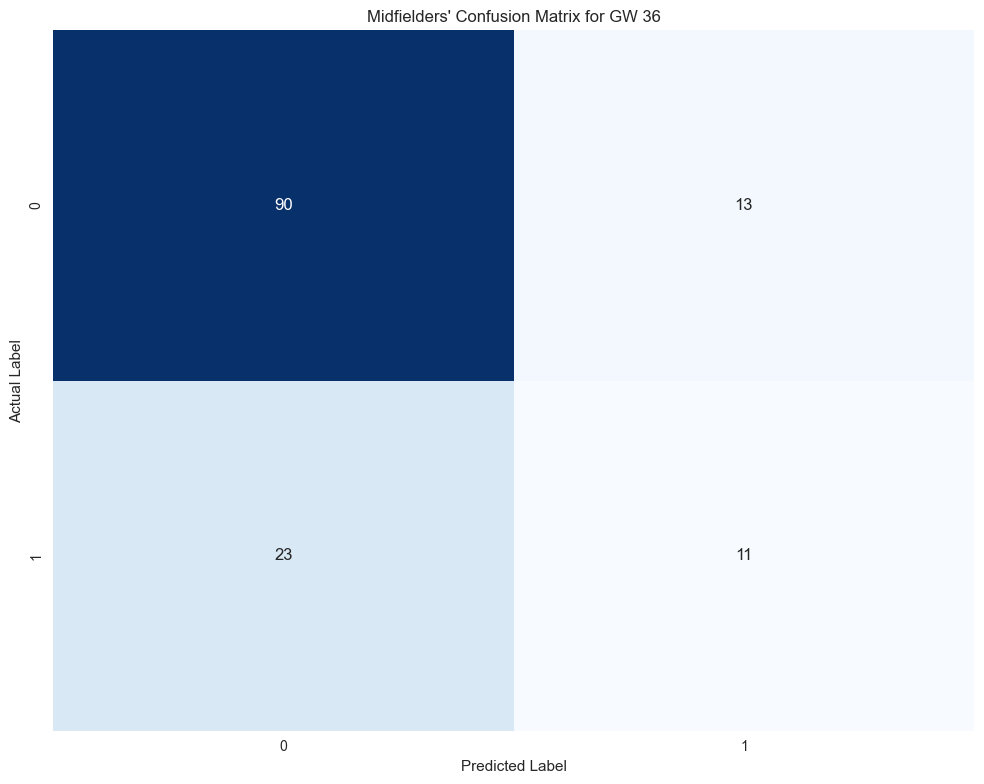

In [93]:
data_36_mid_cs = data_36_mid[cs_features]
cs = data_36_mid_cs[['clean_sheets']].copy()
data_36_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_36 = predict_model(mid_cs_model, data=data_36_mid_cs)
cs_preds_36 = cs_preds_36.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_36 to data_36_mid
data_36_mid['cs_preds'] = cs_preds_36[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_36[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



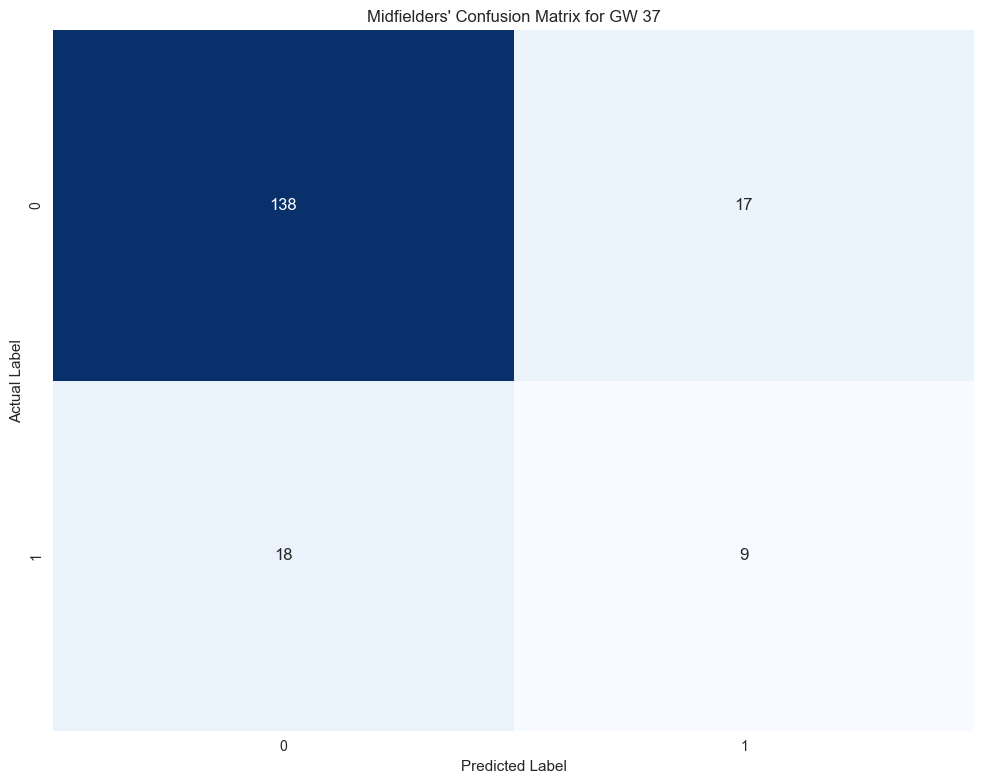

In [94]:
data_37_mid_cs = data_37_mid[cs_features]
cs = data_37_mid_cs[['clean_sheets']].copy()
data_37_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_37 = predict_model(mid_cs_model, data=data_37_mid_cs)
cs_preds_37 = cs_preds_37.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_37 to data_37_mid
data_37_mid['cs_preds'] = cs_preds_37[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_37[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



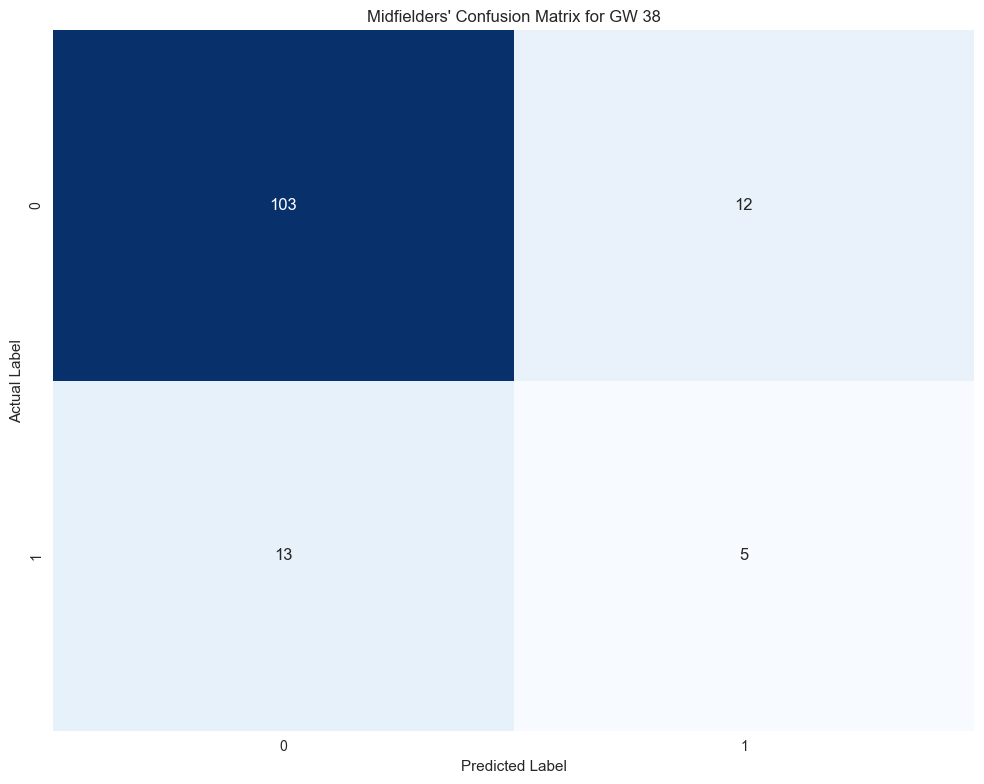

In [95]:
data_38_mid_cs = data_38_mid[cs_features]
cs = data_38_mid_cs[['clean_sheets']].copy()
data_38_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_38 = predict_model(mid_cs_model, data=data_38_mid_cs)
cs_preds_38 = cs_preds_38.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_38 to data_38_mid
data_38_mid['cs_preds'] = cs_preds_38[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_38[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



# Yellow Cards


In [96]:
y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',

                'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


In [97]:
# Load model
g_y_model = load_model('../gk_y_model')

Transformation Pipeline and Model Successfully Loaded


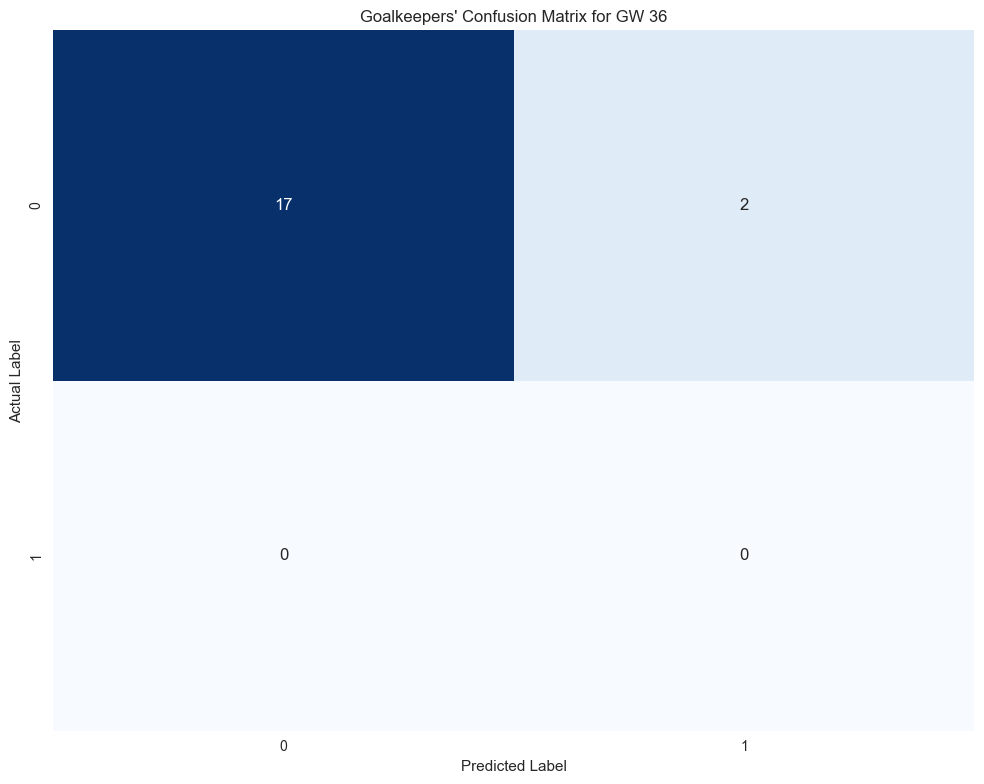

In [98]:
data_36_gk_y = data_36_gk[y_features]
y = data_36_gk_y[['yellow_cards']].copy()
data_36_gk_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_36 = predict_model(g_y_model, data=data_36_gk_y)
y_preds_36 = y_preds_36.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_36 to data_36_gk
data_36_gk['y_preds'] = y_preds_36[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_36[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



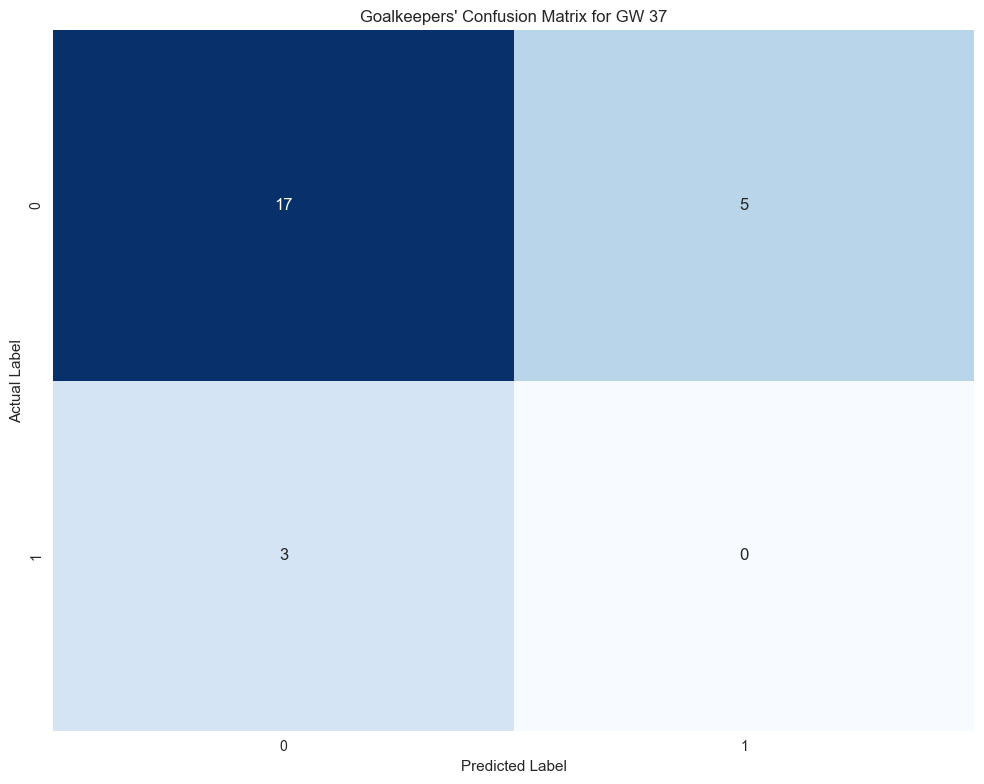

In [99]:
data_37_gk_y = data_37_gk[y_features]
y = data_37_gk_y[['yellow_cards']].copy()
data_37_gk_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_37 = predict_model(g_y_model, data=data_37_gk_y)
y_preds_37 = y_preds_37.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_37 to data_37_gk
data_37_gk['y_preds'] = y_preds_37[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_37[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



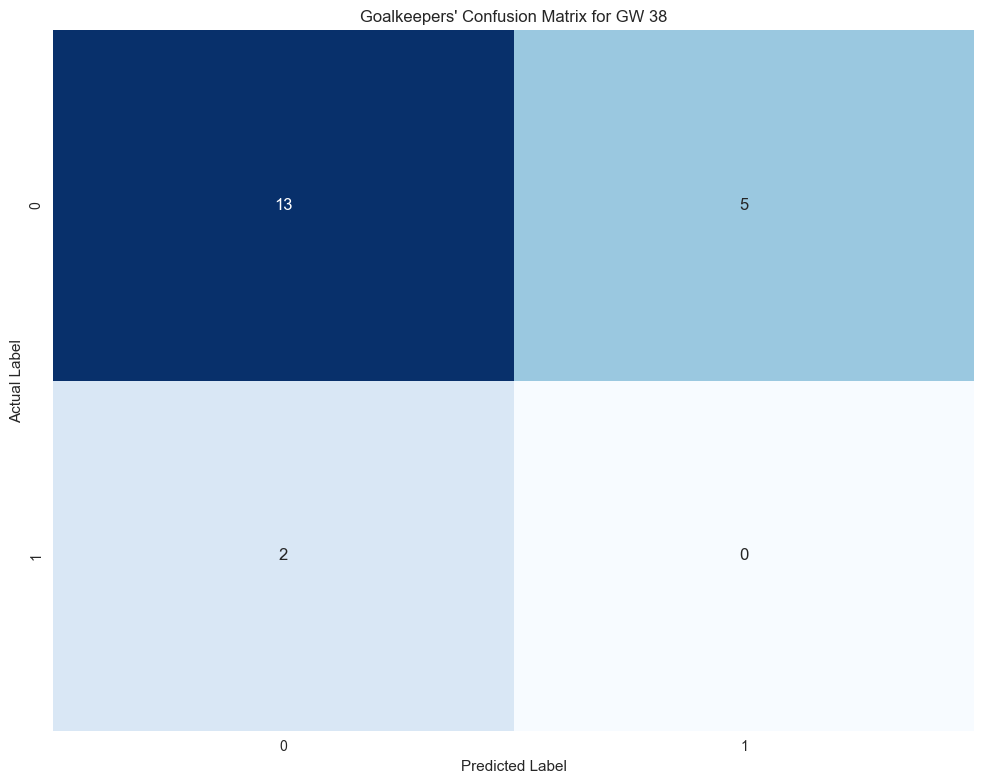

In [100]:
data_38_gk_y = data_38_gk[y_features]
y = data_38_gk_y[['yellow_cards']].copy()
data_38_gk_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_38 = predict_model(g_y_model, data=data_38_gk_y)
y_preds_38 = y_preds_38.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_38 to data_38_gk
data_38_gk['y_preds'] = y_preds_38[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_38[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## DEF


In [101]:
# Load model
def_y_model = load_model('../def_y_model')

Transformation Pipeline and Model Successfully Loaded


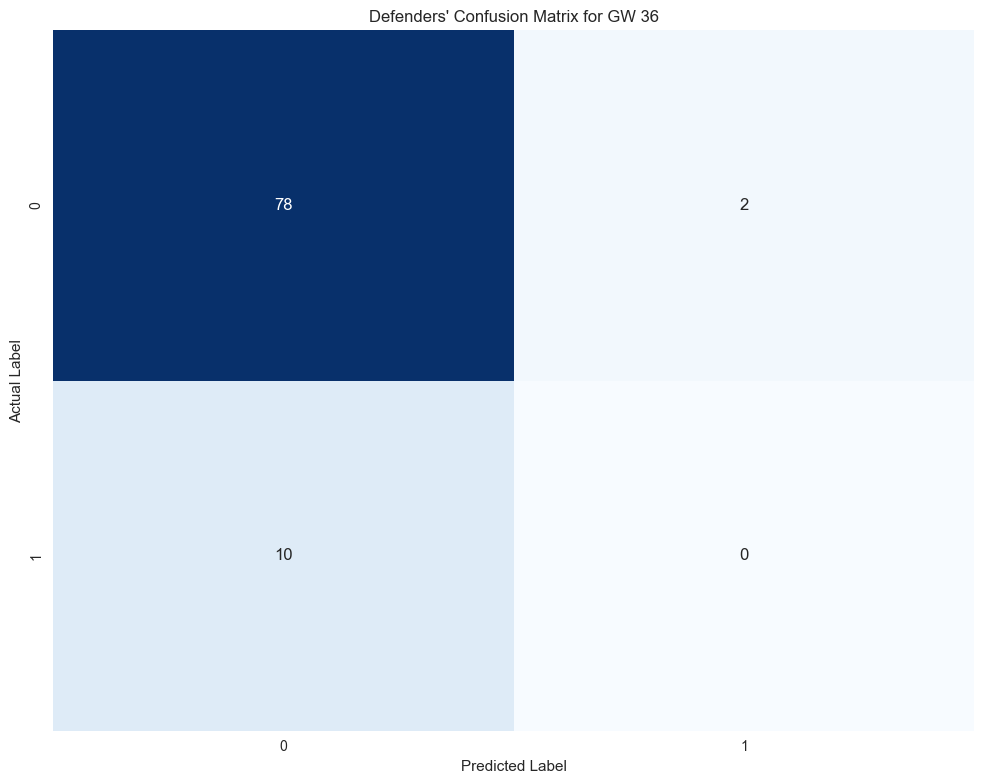

In [102]:
data_36_def_y = data_36_def[y_features]
y = data_36_def_y[['yellow_cards']].copy()
data_36_def_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_36 = predict_model(def_y_model, data=data_36_def_y)
y_preds_36 = y_preds_36.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_36 to data_36_def
data_36_def['y_preds'] = y_preds_36[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_36[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



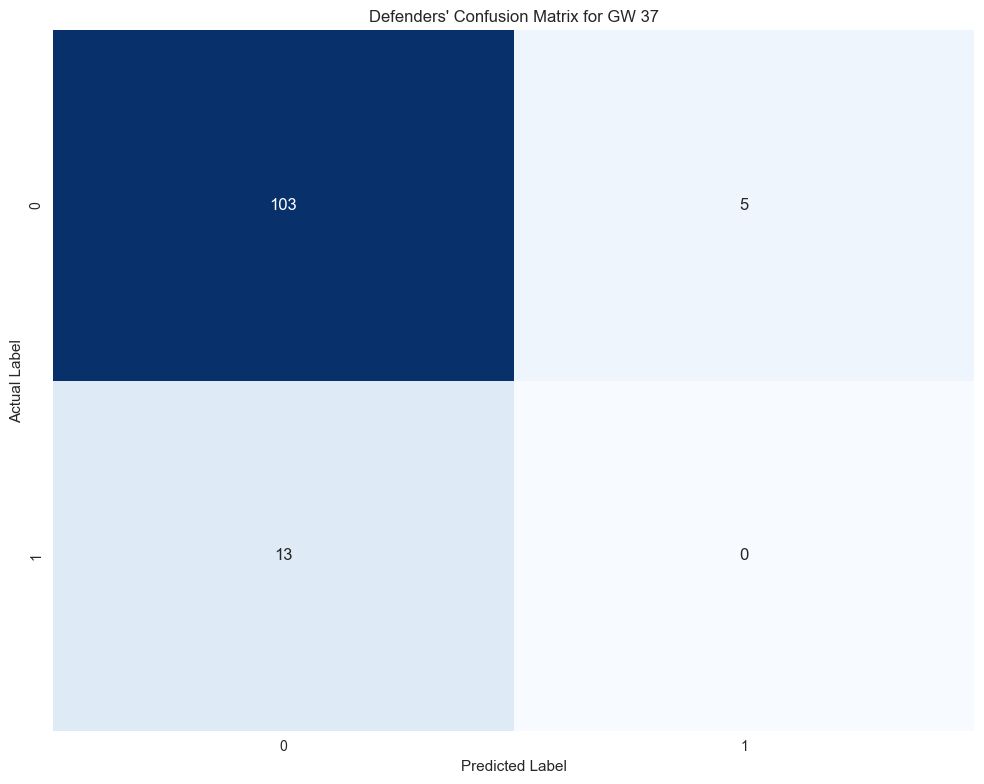

In [103]:
data_37_def_y = data_37_def[y_features]
y = data_37_def_y[['yellow_cards']].copy()
data_37_def_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_37 = predict_model(def_y_model, data=data_37_def_y)
y_preds_37 = y_preds_37.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_37 to data_37_def
data_37_def['y_preds'] = y_preds_37[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_37[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



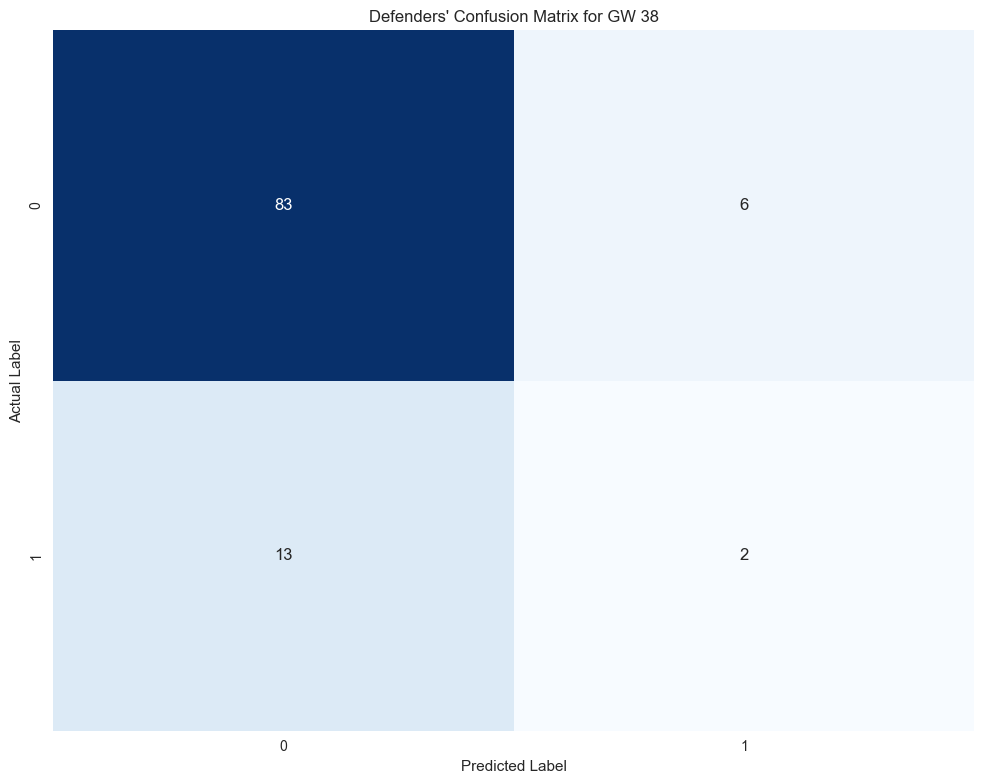

In [104]:
data_38_def_y = data_38_def[y_features]
y = data_38_def_y[['yellow_cards']].copy()
data_38_def_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_38 = predict_model(def_y_model, data=data_38_def_y)
y_preds_38 = y_preds_38.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_38 to data_38_def
data_38_def['y_preds'] = y_preds_38[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_38[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## MID


In [105]:
# Load model
mid_y_model = load_model('../mid_y_model')

Transformation Pipeline and Model Successfully Loaded


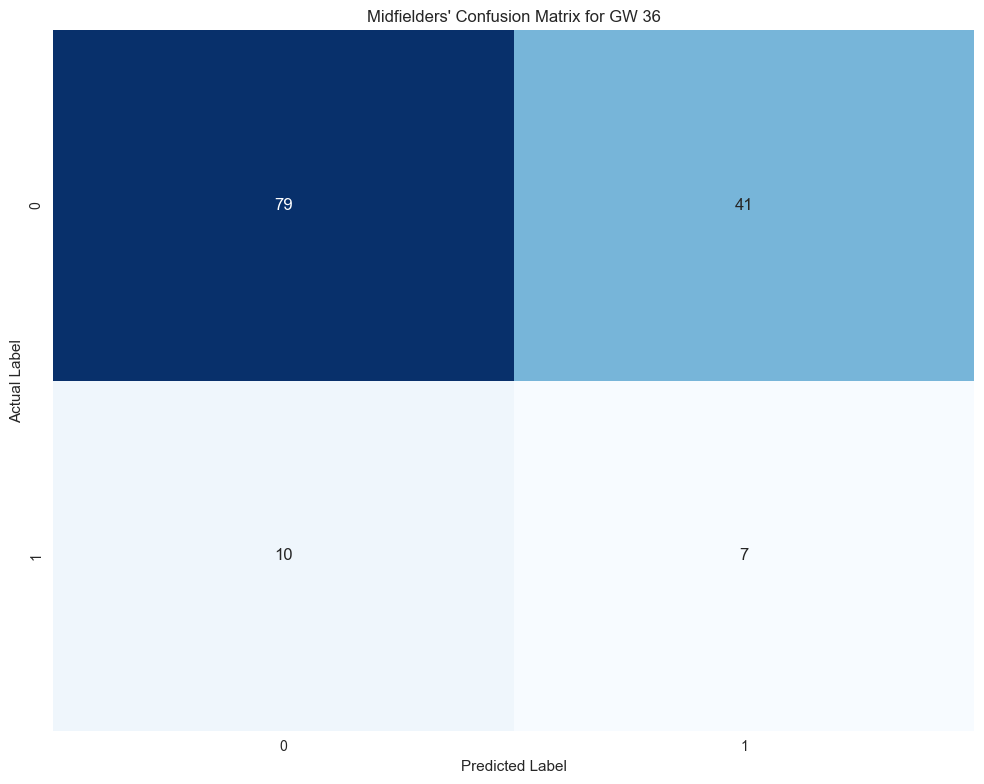

In [106]:
data_36_mid_y = data_36_mid[y_features]
y = data_36_mid_y[['yellow_cards']].copy()
data_36_mid_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_36 = predict_model(mid_y_model, data=data_36_mid_y)
y_preds_36 = y_preds_36.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_36 to data_36_mid
data_36_mid['y_preds'] = y_preds_36[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_36[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



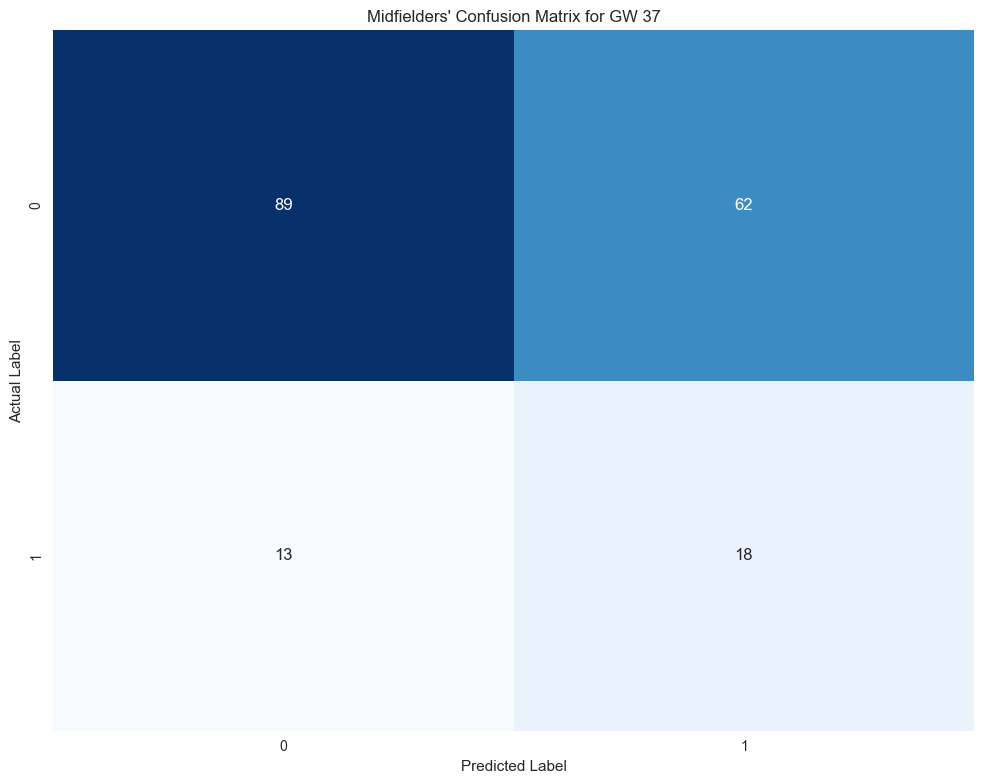

In [107]:
data_37_mid_y = data_37_mid[y_features]
y = data_37_mid_y[['yellow_cards']].copy()
data_37_mid_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_37 = predict_model(mid_y_model, data=data_37_mid_y)
y_preds_37 = y_preds_37.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_37 to data_37_mid
data_37_mid['y_preds'] = y_preds_37[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_37[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



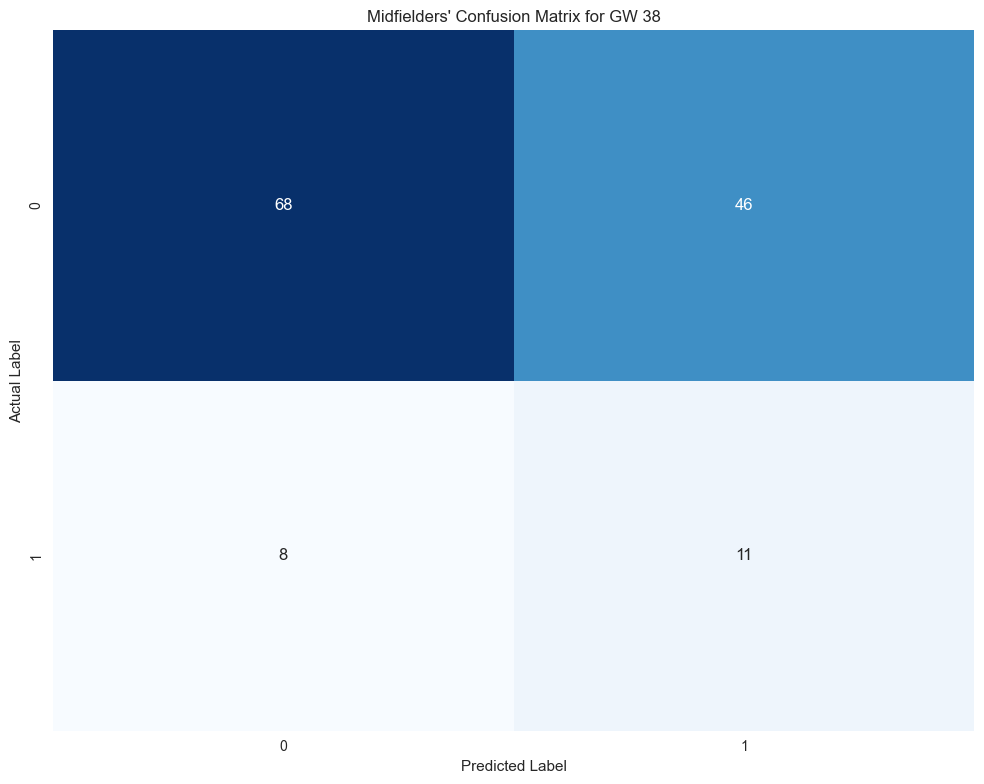

In [108]:
data_38_mid_y = data_38_mid[y_features]
y = data_38_mid_y[['yellow_cards']].copy()
data_38_mid_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_38 = predict_model(mid_y_model, data=data_38_mid_y)
y_preds_38 = y_preds_38.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_38 to data_38_mid
data_38_mid['y_preds'] = y_preds_38[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_38[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## FWD


In [109]:
# Load model
fwd_y_model = load_model('../fwd_y_model')

Transformation Pipeline and Model Successfully Loaded


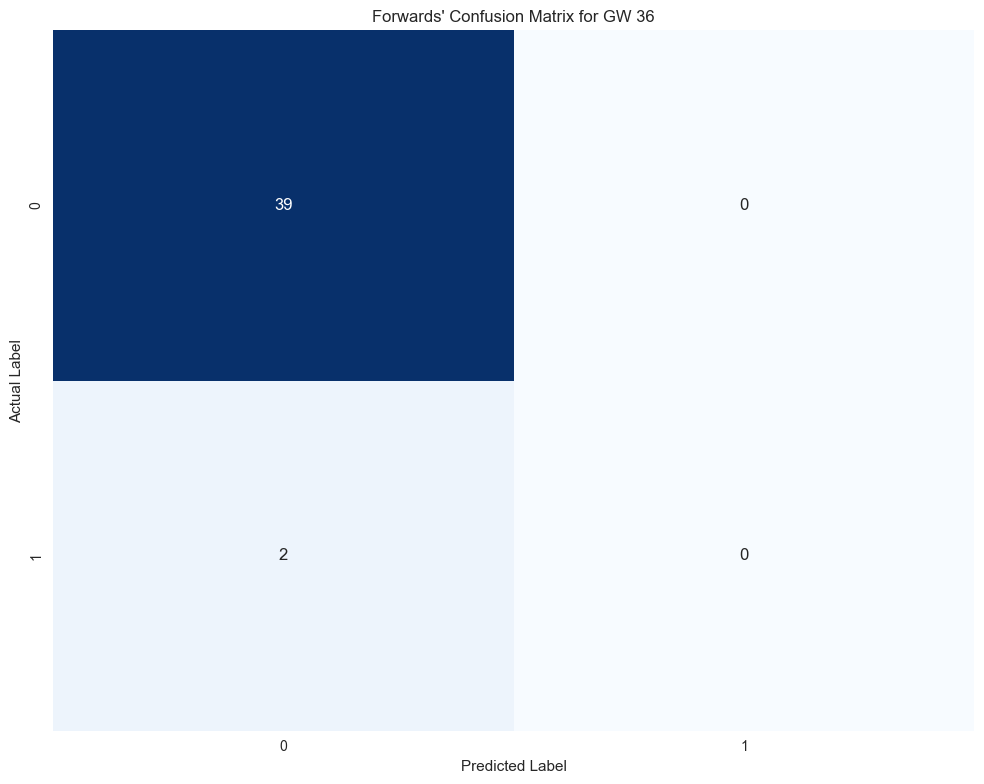

In [110]:
data_36_fwd_y = data_36_fwd[y_features]
y = data_36_fwd_y[['yellow_cards']].copy()
data_36_fwd_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_36 = predict_model(fwd_y_model, data=data_36_fwd_y)
y_preds_36 = y_preds_36.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_36 to data_36_fwd
data_36_fwd['y_preds'] = y_preds_36[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_36[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Forwards\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



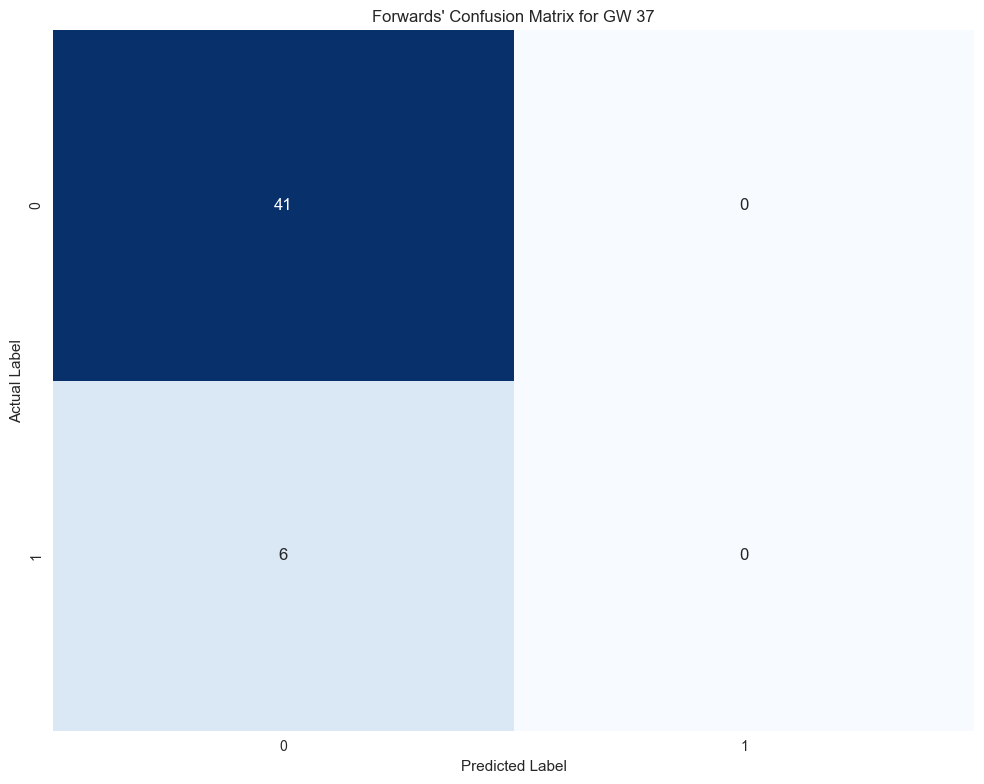

In [111]:
data_37_fwd_y = data_37_fwd[y_features]
y = data_37_fwd_y[['yellow_cards']].copy()
data_37_fwd_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_37 = predict_model(fwd_y_model, data=data_37_fwd_y)
y_preds_37 = y_preds_37.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_37 to data_37_fwd
data_37_fwd['y_preds'] = y_preds_37[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_37[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Forwards\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



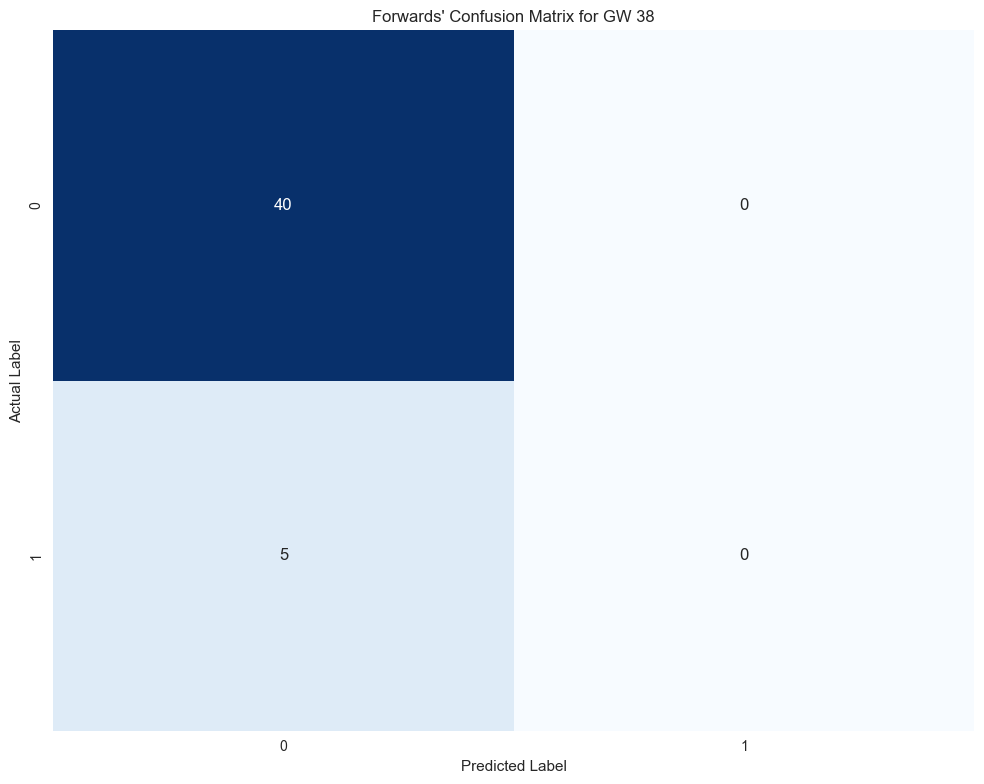

In [112]:
data_38_fwd_y = data_38_fwd[y_features]
y = data_38_fwd_y[['yellow_cards']].copy()
data_38_fwd_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_38 = predict_model(fwd_y_model, data=data_38_fwd_y)
y_preds_38 = y_preds_38.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_38 to data_38_fwd
data_38_fwd['y_preds'] = y_preds_38[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_38[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Forwards\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



# Combine Gw data predictions


In [113]:
# data_36 = pd.read_csv('./data_36_with_preds.csv', index_col=0)
data_36

,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,...,npxG_5,xGChain_5,xGBuildup_5,xP_5,ownership_change,percenatge_net_transfers,pts_bps,whh,whd,wha
8,0,0,4,0,0.5,530,0.00,0.00,0.00,0.68,...,0.00,0.05,0.04,0.28,-243.0,-0.235955,1.0,0.577,0.212,0.212
58,0,0,12,0,16.6,401,0.05,0.05,0.00,1.47,...,0.00,0.49,0.45,1.30,3188.0,0.317313,0.0,0.402,0.255,0.342
91,0,0,4,0,0.8,249,0.01,0.05,0.04,0.56,...,0.09,0.22,0.11,3.46,665.0,0.054168,1.0,0.365,0.263,0.372
145,0,0,7,0,1.7,84,0.01,0.01,0.00,3.89,...,0.00,0.40,0.29,4.86,-5243.0,-0.745459,0.0,0.785,0.128,0.087
158,0,2,27,1,11.3,153,0.01,0.01,0.00,0.06,...,0.02,0.40,0.39,0.68,247.0,0.465812,6.0,0.350,0.257,0.393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10686,0,0,2,0,4.3,660,0.02,0.05,0.03,3.58,...,0.07,0.62,0.29,2.10,192.0,0.046892,2.0,0.278,0.237,0.485
10733,0,0,2,0,4.7,119,0.05,0.05,0.00,0.55,...,0.32,0.66,0.29,3.58,7501.0,0.165845,1.0,0.453,0.250,0.297
10783,0,0,0,0,0.3,645,0.01,0.01,0.00,0.25,...,0.01,0.09,0.02,0.24,241.0,0.368421,1.0,0.365,0.263,0.372
10812,0,0,4,0,15.5,493,0.04,0.08,0.04,3.22,...,0.03,0.25,0.23,2.10,-26.0,-0.243077,1.0,0.641,0.167,0.192


In [114]:
## GW 36
# Merge all the preds and sort by index
preds_36 = pd.concat([data_36_gk, data_36_def, data_36_mid, data_36_fwd]).sort_index()
cols_to_add = ['y_preds', 'cs_preds']

# Call the gw preds saved from the regressor
data_36 = pd.read_csv('./data_36_with_preds.csv', index_col=0)
# Now add the columns to the gw_data
data_36[cols_to_add] = preds_36[cols_to_add]

# Save the updated DataFrame
data_36.to_csv('./data_36_with_preds.csv')


## GW 37
# Merge all the preds and sort by index
preds_37 = pd.concat([data_37_gk, data_37_def, data_37_mid, data_37_fwd]).sort_index()
cols_to_add = ['y_preds', 'cs_preds']

# Call the gw preds saved from the regressor
data_37 = pd.read_csv('./data_37_with_preds.csv', index_col=0)
# Now add the columns to the gw_data
data_37[cols_to_add] = preds_37[cols_to_add]

# Save the updated DataFrame
data_37.to_csv('./data_37_with_preds.csv')

## GW 38
# Merge all the preds and sort by index
preds_38 = pd.concat([data_38_gk, data_38_def, data_38_mid, data_38_fwd]).sort_index()
cols_to_add = ['y_preds', 'cs_preds']

# Call the gw preds saved from the regressor
data_38 = pd.read_csv('./data_38_with_preds.csv', index_col=0)
# Now add the columns to the gw_data
data_38[cols_to_add] = preds_38[cols_to_add]

# Save the updated DataFrame
data_38.to_csv('./data_38_with_preds.csv')
